#$$
 \textbf{Projects in Machine Learning (ML) and Artificial Intelligence (AI)}
$$

 # $$
 \textbf{CSCI 6967}
 $$

 # $$
 \textbf{Homework 5}
 $$

#Task for 6000 level (Graduate level only): 100 points
Medical Image Segmentation is an important problem in healthcare domain. Polyp recognition
and segmentation is one field which helps doctors identify polyps from colonoscope images.
CVC-Clinic database consists of frames extracted from colonoscopy videos. The dataset contains
several examples of polyp frames & corresponding ground truth for them.
The Ground Truth image consists of a mask corresponding to the region covered by the polyp in
the image. The data is available in both .png and .tiff format here: https://polyp.grandchallenge.org/CVCClinicDB/
Consider this task as a minor research project in which you should research the existing models
used (https://paperswithcode.com/dataset/cvc-clinicdb ) to identify polyps from these images.
Report on the key findings and the evaluation metrics used for this problem. Variants of the
Unet architecture are often used to solve this problem. Implement either Unet or any of its
variants (Unet++, ResUnet etc.) to segment the polyp images. This may be a computation
intensive task (requiring GPUs). In case you do not have access to GPUs simply reduce your
training data size to train your model. Report your results, compare and contrast these results
with at least 2 of the other research paper results.

In [2]:
# ================== STEP 1: MOUNT DRIVE AND INSTALL DEPENDENCIES ==================
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow opencv-python scikit-learn matplotlib

# ================== STEP 2: IMPORT LIBRARIES ==================
import os
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

# ================== STEP 3: SET PATHS (UPDATE THESE) ==================
image_dir = '/content/drive/MyDrive/CVC-ClinicDB/Original'  # Example path to your images
mask_dir = '/content/drive/MyDrive/CVC-ClinicDB/Ground Truth'  # Example path to your masks

# Image dimensions
IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS = 256, 256, 3

# ================== STEP 4: LOAD AND PREPROCESS DATA ==================
def load_data(image_dir, mask_dir):
    images, masks = [], []

    # List all files in the directory and sort them to match
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))

    for img_file, mask_file in zip(image_files, mask_files):
        # Full paths
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)

        # Load the image
        img = cv2.imread(img_path)
        # If reading fails, skip
        if img is None:
            continue
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Resize to desired dimensions
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        # Normalize
        img = img / 255.0

        # Load the mask (grayscale)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        # Resize mask
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
        # Expand to (H, W, 1)
        mask = np.expand_dims(mask, axis=-1)
        # Normalize
        mask = mask / 255.0
        # Binarize (optional, ensures strictly 0 or 1)
        mask = (mask > 0.5).astype(np.float32)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

# Load the dataset
images, masks = load_data(image_dir, mask_dir)
print(f"Images shape: {images.shape}")
print(f"Masks shape:  {masks.shape}")

# ================== STEP 5: SPLIT DATA INTO TRAIN/VALIDATION ==================
X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.40, random_state=42)
print("Train set:", X_train.shape, y_train.shape)
print("Val set:", X_val.shape, y_val.shape)

# ================== STEP 6: DEFINE THE UNET MODEL ==================
def build_unet(input_shape):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # Bottleneck
    bn = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    bn = layers.Conv2D(256, 3, activation='relu', padding='same')(bn)

    # Decoder
    u1 = layers.UpSampling2D((2,2))(bn)
    concat1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(concat1)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D((2,2))(c3)
    concat2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(concat2)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

# Create and compile the model
model = build_unet((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# ================== STEP 7: TRAIN THE MODEL ==================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=4,
    validation_data=(X_val, y_val),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_unet.h5', save_best_only=True)
    ]
)

# ================== STEP 8: PLOT TRAINING HISTORY ==================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.show()

# ================== STEP 9: VISUALIZE SAMPLE PREDICTIONS ==================
predictions = model.predict(X_val[:3])

for i in range(3):
    plt.figure(figsize=(12,4))

    # Original image
    plt.subplot(1,3,1)
    plt.imshow(X_val[i])
    plt.title("Input Image")
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(1,3,2)
    plt.imshow(y_val[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow((predictions[i].squeeze() > 0.5), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images shape: (612, 256, 256, 3)
Masks shape:  (612, 256, 256, 1)


KeyboardInterrupt: 

In [ ]:
######################################################
# STEP 1: MOUNT DRIVE AND INSTALL DEPENDENCIES
######################################################
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow opencv-python scikit-learn matplotlib

######################################################
# STEP 2: IMPORT LIBRARIES
######################################################
import os
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

######################################################
# STEP 3: SET PATHS (UPDATE THESE)
######################################################
img_directory = '/content/drive/MyDrive/CVC-ClinicDB/Original'    # Example path to your images
mask_directory = '/content/drive/MyDrive/CVC-ClinicDB/Ground Truth'  # Example path to your masks

# Image dimensions
IMG_H, IMG_W, IMG_C = 256, 256, 3

######################################################
# STEP 4: LOAD AND PREPROCESS DATA
######################################################
def load_dataset(img_dir, msk_dir):
    img_data, mask_data = [], []

    # List all files in the directory and sort them to match
    img_files = sorted(os.listdir(img_dir))
    msk_files = sorted(os.listdir(msk_dir))

    for img_file, msk_file in zip(img_files, msk_files):
        # Full paths
        img_path = os.path.join(img_dir, img_file)
        msk_path = os.path.join(msk_dir, msk_file)

        # Load the image
        img = cv2.imread(img_path)
        if img is None:
            continue
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Resize to desired dimensions
        img = cv2.resize(img, (IMG_W, IMG_H))
        # Normalize
        img = img / 255.0

        # Load the mask (grayscale)
        mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        # Resize mask
        mask = cv2.resize(mask, (IMG_W, IMG_H))
        # Expand to (H, W, 1)
        mask = np.expand_dims(mask, axis=-1)
        # Normalize
        mask = mask / 255.0
        # Binarize (optional, ensures strictly 0 or 1)
        mask = (mask > 0.5).astype(np.float32)

        img_data.append(img)
        mask_data.append(mask)

    return np.array(img_data), np.array(mask_data)

# Load the dataset
images, masks = load_dataset(img_directory, mask_directory)
print(f"Images shape: {images.shape}")
print(f"Masks shape:  {masks.shape}")

######################################################
# STEP 5: SPLIT DATA INTO TRAIN/VALIDATION
######################################################
Xtrain, Xvalid, Ytrain, Yvalid = train_test_split(
    images, masks, test_size=0.40, random_state=42
)
print("Train set:", Xtrain.shape, Ytrain.shape)
print("Val set:", Xvalid.shape, Yvalid.shape)

######################################################
# STEP 6: DEFINE THE UNET MODEL
######################################################
def build_unet_model(input_shape):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # Bottleneck
    bn = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    bn = layers.Conv2D(256, 3, activation='relu', padding='same')(bn)

    # Decoder
    u1 = layers.UpSampling2D((2,2))(bn)
    concat1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(concat1)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D((2,2))(c3)
    concat2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(concat2)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

# Create and compile the model
unet_model = build_unet_model((IMG_H, IMG_W, IMG_C))
unet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

unet_model.summary()

######################################################
# STEP 7: TRAIN THE MODEL
######################################################
train_history = unet_model.fit(
    Xtrain, Ytrain,
    epochs=20,
    batch_size=4,
    validation_data=(Xvalid, Yvalid),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_unet.h5', save_best_only=True)
    ]
)

######################################################
# STEP 8: PLOT TRAINING HISTORY
######################################################
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_history.history['loss'], label='Train Loss')
plt.plot(train_history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_history.history['accuracy'], label='Train Accuracy')
plt.plot(train_history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.show()

######################################################
# STEP 9: VISUALIZE SAMPLE PREDICTIONS
######################################################
seg_predictions = unet_model.predict(Xvalid[:3])

for i in range(3):
    plt.figure(figsize=(12,4))

    # Original image
    plt.subplot(1,3,1)
    plt.imshow(Xvalid[i])
    plt.title("Input Image")
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(1,3,2)
    plt.imshow(Yvalid[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow((seg_predictions[i].squeeze() > 0.5), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images shape: (612, 256, 256, 3)
Masks shape: (612, 256, 256, 1)
Training set: (367, 256, 256, 3) (367, 256, 256, 1)
Validation set: (245, 256, 256, 3) (245, 256, 256, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 64)   │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 128)  │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 128)  │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 64, 64, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d             │ (None, 128, 128, 256)  │              0 │ conv2d_5[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 128, 128, 384)  │              0 │ up_sampling2d[0][0],   │
│                           │                        │                │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 128, 128, 128)  │        442,496 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 128, 128, 128)  │        147,584 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_1           │ (None, 256, 256, 128)  │              0 │ conv2d_7[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 256, 256, 192)  │              0 │ up_sampling2d_1[0][0], │
│ (Concatenate)             │                        │                │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 256, 256, 64)   │        110,656 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)    

 Total params: 1,883,137 (7.18 MB)

 Trainable params: 1,883,137 (7.18 MB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 2050s 22s/step - accuracy: 0.9105 - loss: 0.2631 - val_accuracy: 0.9125 - val_loss: 0.2493
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2036s 22s/step - accuracy: 0.9016 - loss: 0.2704 - val_accuracy: 0.9125 - val_loss: 0.2836
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.9061 - loss: 0.2717 

92/92 ━━━━━━━━━━━━━━━━━━━━ 2080s 22s/step - accuracy: 0.9061 - loss: 0.2716 - val_accuracy: 0.9125 - val_loss: 0.2414
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2053s 22s/step - accuracy: 0.9033 - loss: 0.2644 - val_accuracy: 0.9125 - val_loss: 0.2564
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2041s 22s/step - accuracy: 0.9087 - loss: 0.2605 - val_accuracy: 0.9125 - val_loss: 0.2526
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2059s 22s/step - accuracy: 0.8971 - loss: 0.2651 - val_accuracy: 0.9125 - val_loss: 0.2454
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.9060 - loss: 0.2596 

92/92 ━━━━━━━━━━━━━━━━━━━━ 2059s 22s/step - accuracy: 0.9060 - loss: 0.2596 - val_accuracy: 0.9125 - val_loss: 0.2413
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.9046 - loss: 0.2607 

92/92 ━━━━━━━━━━━━━━━━━━━━ 2046s 22s/step - accuracy: 0.9046 - loss: 0.2606 - val_accuracy: 0.9125 - val_loss: 0.2385
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8999 - loss: 0.2626 

92/92 ━━━━━━━━━━━━━━━━━━━━ 2015s 22s/step - accuracy: 0.9000 - loss: 0.2626 - val_accuracy: 0.9125 - val_loss: 0.2382
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2079s 22s/step - accuracy: 0.9016 - loss: 0.2675 - val_accuracy: 0.9125 - val_loss: 0.2391
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2057s 22s/step - accuracy: 0.9056 - loss: 0.2535 - val_accuracy: 0.9125 - val_loss: 0.2393
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2069s 22s/step - accuracy: 0.9083 - loss: 0.2572 - val_accuracy: 0.9125 - val_loss: 0.2417
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2094s 23s/step - accuracy: 0.9035 - loss: 0.2581 - val_accuracy: 0.9125 - val_loss: 0.2404
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2060s 22s/step - accuracy: 0.9106 - loss: 0.2403 - val_accuracy: 0.9125 - val_loss: 0.2493


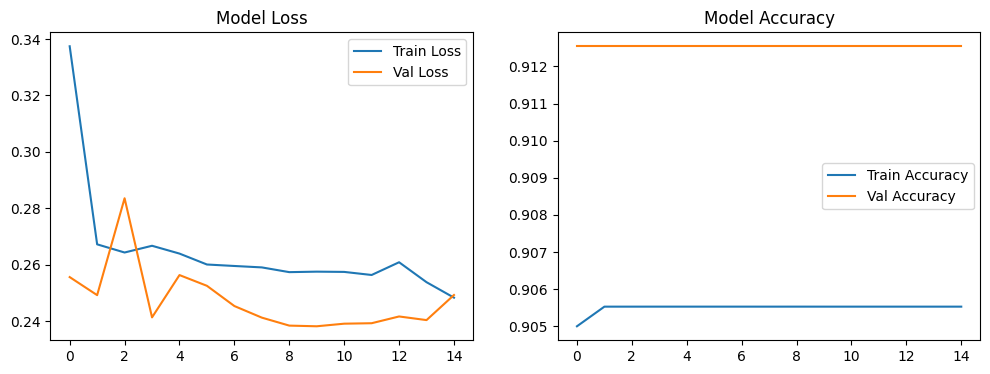

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


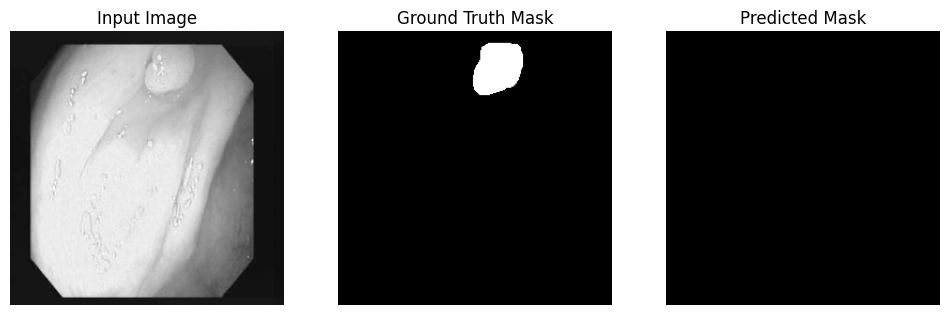

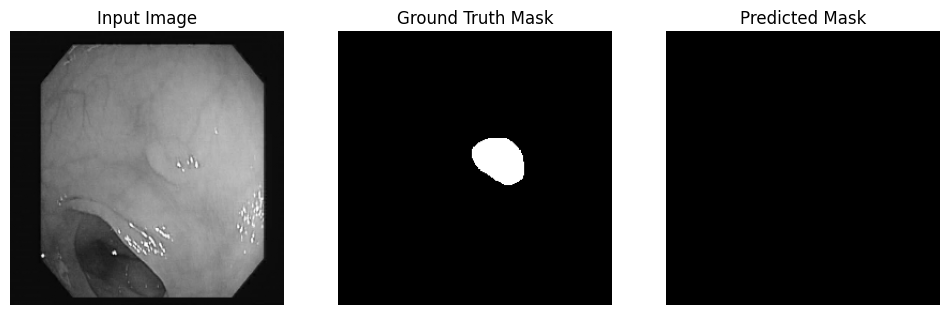

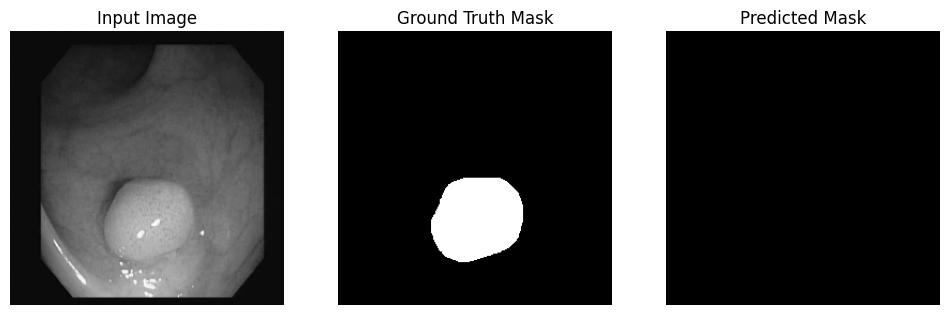

In [1]:
######################################################
# STEP 1: MOUNT DRIVE AND INSTALL DEPENDENCIES
######################################################
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow opencv-python scikit-learn matplotlib

######################################################
# STEP 2: IMPORT REQUIRED LIBRARIES
######################################################
import os
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

######################################################
# STEP 3: CONFIGURE DATA PATHS AND IMAGE PARAMETERS
######################################################
# Update these paths as needed
img_directory = '/content/drive/MyDrive/CVC-ClinicDB/Original'    # Folder with input images
mask_directory = '/content/drive/MyDrive/CVC-ClinicDB/Ground Truth' # Folder with segmentation masks

# Define image dimensions and channels
IMG_H, IMG_W, IMG_C = 256, 256, 3

######################################################
# STEP 4: LOAD AND PREPROCESS THE DATASET
######################################################
def load_dataset(image_dir, mask_dir):
    images_list, masks_list = [], []

    # Get sorted list of filenames to ensure correct matching
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))

    for img_file, mask_file in zip(image_files, mask_files):
        # Construct full paths
        full_img_path = os.path.join(image_dir, img_file)
        full_mask_path = os.path.join(mask_dir, mask_file)

        # Read and process the image
        image = cv2.imread(full_img_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_W, IMG_H))
        image = image / 255.0  # Normalize to [0, 1]

        # Read and process the mask (grayscale)
        mask = cv2.imread(full_mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        mask = cv2.resize(mask, (IMG_W, IMG_H))
        mask = np.expand_dims(mask, axis=-1)
        mask = mask / 255.0  # Normalize to [0, 1]
        mask = (mask > 0.5).astype(np.float32)  # Binarize the mask

        images_list.append(image)
        masks_list.append(mask)

    return np.array(images_list), np.array(masks_list)

# Load dataset and print shapes
images, masks = load_dataset(img_directory, mask_directory)
print(f"Images shape: {images.shape}")
print(f"Masks shape: {masks.shape}")

######################################################
# STEP 5: SPLIT THE DATA INTO TRAINING AND VALIDATION SETS
######################################################
Xtrain, Xvalid, Ytrain, Yvalid = train_test_split(
    images, masks, test_size=0.40, random_state=42
)
print("Training set:", Xtrain.shape, Ytrain.shape)
print("Validation set:", Xvalid.shape, Yvalid.shape)

######################################################
# STEP 6: DEFINE THE U-NET ARCHITECTURE
######################################################
def build_unet_model(input_shape):
    inputs = layers.Input(input_shape)

    # Encoder Path
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D((2,2))(conv1)

    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D((2,2))(conv2)

    # Bottleneck
    bottleneck = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    bottleneck = layers.Conv2D(256, 3, activation='relu', padding='same')(bottleneck)

    # Decoder Path
    up1 = layers.UpSampling2D((2,2))(bottleneck)
    merge1 = layers.concatenate([up1, conv2])
    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(merge1)
    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv3)

    up2 = layers.UpSampling2D((2,2))(conv3)
    merge2 = layers.concatenate([up2, conv1])
    conv4 = layers.Conv2D(64, 3, activation='relu', padding='same')(merge2)
    conv4 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv4)

    # Output Layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv4)

    return models.Model(inputs, outputs)

# Build and compile the U-Net model
unet_model = build_unet_model((IMG_H, IMG_W, IMG_C))
unet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
unet_model.summary()

######################################################
# STEP 7: TRAIN THE MODEL
######################################################
train_history = unet_model.fit(
    Xtrain, Ytrain,
    epochs=20,
    batch_size=4,
    validation_data=(Xvalid, Yvalid),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_unet.h5', save_best_only=True)
    ]
)

######################################################
# STEP 8: PLOT TRAINING HISTORY
######################################################
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_history.history['loss'], label='Train Loss')
plt.plot(train_history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Model Loss")

plt.subplot(1,2,2)
plt.plot(train_history.history['accuracy'], label='Train Accuracy')
plt.plot(train_history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Model Accuracy")

plt.show()

######################################################
# STEP 9: VISUALIZE SAMPLE PREDICTIONS
######################################################
seg_predictions = unet_model.predict(Xvalid[:3])

for i in range(3):
    plt.figure(figsize=(12,4))

    # Display the original image
    plt.subplot(1,3,1)
    plt.imshow(Xvalid[i])
    plt.title("Input Image")
    plt.axis('off')

    # Display the ground truth mask
    plt.subplot(1,3,2)
    plt.imshow(Yvalid[i].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Display the predicted mask
    plt.subplot(1,3,3)
    plt.imshow((seg_predictions[i].squeeze() > 0.5), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.show()
